# 1. SETUP

##1.1 Mount Colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/567-Semester-Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
%cd "$PROJECT_DIR"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/567-Semester-Project


##1.2 Repo Cloning

In [10]:
import os
REPO_DIR = '/content/drive/MyDrive/567-Semester-Project'

# To clone a specific branch instead of main, add the `-b <branch_name>` flag to your `git clone` command.
# Check if the repository has already been cloned by looking for the .git directory
if not os.path.exists(os.path.join(REPO_DIR, '.git')):
    print(f"Cloning repository into {REPO_DIR}...")
    os.makedirs(REPO_DIR, exist_ok=True) # Ensure the directory exists before cloning into it
    !git clone https://github.com/AbhinavSurendra/Full-Press-ML.git "$REPO_DIR"
else:
    print(f"Repository already exists at {REPO_DIR}, performing git pull...")
    %cd "$REPO_DIR"
    !git pull

%cd "$REPO_DIR"
!ls

Repository already exists at /content/drive/MyDrive/567-Semester-Project, performing git pull...
/content/drive/MyDrive/567-Semester-Project
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 570 bytes | 0 bytes/s, done.
From https://github.com/AbhinavSurendra/Full-Press-ML
   eb4776c..eab5b0a  nic/feature-engineering -> origin/nic/feature-engineering
Updating eb4776c..eab5b0a
Fast-forward
 src/full_press_ml/features/engineer.py | 1 +
 1 file changed, 1 insertion(+)
/content/drive/MyDrive/567-Semester-Project
'567 Initial Project Presentation.pdf'	   PROJECT_PLAN.md
'567 Project  Check in Presentation.pdf'   pyproject.toml
'567 Project Proposal.pdf'		   README.md
 configs				   REPORT.md
 data					   scripts
 DATA_SCHEMA_AND_JOIN.md		   src
 FEATURE_ENGINEERING_PLAN.md		   tasks
"Nic's_copy_of_FullPressML.i

## 1.2.1 Switch Branch and Pull

In [11]:
import os
REPO_DIR = '/content/drive/MyDrive/567-Semester-Project'
BRANCH = 'nic/feature-engineering'


if os.path.exists(os.path.join(REPO_DIR, '.git')):
    print(f"Switching to branch: {BRANCH}")
    %cd "$REPO_DIR"
    !git fetch origin
    # Checkout the branch and pull latest
    !git checkout {BRANCH}
    !git pull origin {BRANCH}
    !git branch
else:
    print("Repository not found. Please run the cloning cell above first.")

Switching to branch: nic/feature-engineering
/content/drive/MyDrive/567-Semester-Project
M	scripts/setup_venv.sh
Already on 'nic/feature-engineering'
Your branch is up to date with 'origin/nic/feature-engineering'.
From https://github.com/AbhinavSurendra/Full-Press-ML
 * branch            nic/feature-engineering -> FETCH_HEAD
Already up to date.
  main
* nic/feature-engineering


##1.3 Dependecy Install

In [6]:
%cd /content/drive/MyDrive/567-Semester-Project
!pip install -q -e ".[dev]"
!pip install -q py7zr

/content/drive/MyDrive/567-Semester-Project
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 9.6 MB/s eta 0:00:00
  Building editable for full-press-ml (pyproject.toml) ... done


##1.4 Sanity Check GPU setup

In [5]:
import sys, torch
print("python:", sys.version.split()[0])
print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

python: 3.12.13
torch : 2.10.0+cpu
cuda  : False 


# 2. Full Dataset Pipeline
## 2.1 Path setup

In [7]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

import os, sys
REPO_DIR   = '/content/drive/MyDrive/567-Semester-Project'
ARCHIVE_DIR = f'{REPO_DIR}/data/raw/full/archives'   # on Drive (cached)
PBP_PATH    = f'{REPO_DIR}/data/raw/full/2015-16_pbp.csv'
MANIFEST    = f'{REPO_DIR}/data/raw/full/manifest.json'
LOCAL_GAMES = '/content/work/full/games'              # local disk, ephemeral
LOCAL_PROC  = '/content/work/full/processed'          # local disk, fast I/O for frames.csv
PROC_DIR    = f'{REPO_DIR}/data/processed/full_standard'  # on Drive (small artifacts only)

os.makedirs(ARCHIVE_DIR, exist_ok=True)
os.makedirs(LOCAL_GAMES, exist_ok=True)
os.makedirs(LOCAL_PROC, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

SRC = f'{REPO_DIR}/src'
if SRC not in sys.path: sys.path.insert(0, SRC)

os.chdir(REPO_DIR)
!pip install -q py7zr


Mounted at /content/drive


## 2.2 Download all archives (~22 mins)

In [7]:
import json, random, urllib.request, shutil
from pathlib import Path
import py7zr

TRACKING_INDEX_URL = (
    "https://github.com/linouk23/NBA-Player-Movements/"
    "raw/master/data/2016.NBA.Raw.SportVU.Game.Logs"
)
PBP_URL = ("https://github.com/sumitrodatta/nba-alt-awards/"
           "raw/main/Historical/PBP%20Data/2015-16_pbp.csv")

# reuse the upstream script's listing parser — deterministic with seed=9
import importlib.util
spec = importlib.util.spec_from_file_location(
    "dl", f"{REPO_DIR}/scripts/download_tiny_dataset.py")
dl = importlib.util.module_from_spec(spec); spec.loader.exec_module(dl)

items = dl.fetch_listing_items()
random.seed(9)
selected = random.sample(items, len(items))
N = len(selected)
print(f"selected {N} games (full dataset)")

# PBP CSV (small, stays on Drive)
if not Path(PBP_PATH).exists():
    print("downloading play-by-play CSV...")
    with urllib.request.urlopen(PBP_URL) as r, open(PBP_PATH, 'wb') as f:
        shutil.copyfileobj(r, f)

# archives → Drive (cached); extracted JSON → /content (ephemeral)
manifest = []
for i, game in enumerate(selected, 1):
    name = game['name'][:-3]
    archive_path = Path(ARCHIVE_DIR) / f"{name}.7z"
    extract_dir  = Path(LOCAL_GAMES) / name

    if not archive_path.exists():
        url = f"{TRACKING_INDEX_URL}/{name}.7z"
        with urllib.request.urlopen(url) as r, open(archive_path, 'wb') as f:
            shutil.copyfileobj(r, f)

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with py7zr.SevenZipFile(archive_path, mode='r') as z:
            z.extractall(path=extract_dir)

    manifest.append({'game_name': name,
                     'archive_path': str(archive_path),
                     'extract_dir': str(extract_dir)})
    if i % 25 == 0 or i == N: print(f"  {i}/{N} done")

with open(MANIFEST, 'w') as f:
    json.dump({'config': 'full', 'num_games': len(manifest),
               'games': manifest, 'pbp_path': PBP_PATH}, f, indent=2)

!du -sh "$ARCHIVE_DIR" "$LOCAL_GAMES"

selected 636 games (full dataset)
downloading play-by-play CSV...
  25/636 done
  50/636 done
  75/636 done
  100/636 done
  125/636 done
  150/636 done
  175/636 done
  200/636 done
  225/636 done
  250/636 done
  275/636 done
  300/636 done
  325/636 done
  350/636 done
  375/636 done
  400/636 done
  425/636 done
  450/636 done
  475/636 done
  500/636 done
  525/636 done
  550/636 done
  575/636 done
  600/636 done
  625/636 done
  636/636 done
3.6G	/content/drive/MyDrive/567-Semester-Project/data/raw/full/archives
61G	/content/work/full/games


## 2.3 Build rich frames (per-game parquet)

In [ ]:
from pathlib import Path

if not Path(f'{LOCAL_PROC}/rich_frames').exists():
    !python scripts/build_rich_tracking.py \
        --games-dir "$LOCAL_GAMES" \
        --pbp "$PBP_PATH" \
        --output-dir "$LOCAL_PROC"
else:
    print(f"{LOCAL_PROC}/rich_frames already built, skipping")


## 2.4 Save rich frames to Drive

In [ ]:
# Save rich_frames directory (per-game parquet files) to Drive
!rm -rf "$PROC_DIR/rich_frames"
!cp -r "$LOCAL_PROC/rich_frames" "$PROC_DIR/rich_frames"
!cp "$LOCAL_PROC/events.parquet" "$PROC_DIR/events.parquet" 2>/dev/null || true
!cp "$LOCAL_PROC/possessions.parquet" "$PROC_DIR/possessions.parquet" 2>/dev/null || true
print("saved rich_frames/ + events.parquet + possessions.parquet to Drive")


## 2.5 Restore rich frames from Drive (only after runtime disconnect)

In [8]:
# Restore rich frames from Drive to local fast disk.
# Handles both new parquet directory layout AND legacy single rich_frames.csv,
# so the same cell works on a fresh runtime regardless of which format you saved.
import os
from pathlib import Path

os.makedirs(LOCAL_PROC, exist_ok=True)
drive_dir = Path(f'{PROC_DIR}/rich_frames')
drive_csv = Path(f'{PROC_DIR}/rich_frames.csv')

if drive_dir.is_dir() and any(drive_dir.glob('*.parquet')):
    !rm -rf "$LOCAL_PROC/rich_frames"
    !cp -r "$PROC_DIR/rich_frames" "$LOCAL_PROC/rich_frames"
    print(f"restored parquet directory: {LOCAL_PROC}/rich_frames")
elif drive_csv.exists():
    !cp "$PROC_DIR/rich_frames.csv" "$LOCAL_PROC/rich_frames.csv"
    print(f"restored legacy CSV: {LOCAL_PROC}/rich_frames.csv  — run the migration cell next to convert to parquet")
else:
    raise FileNotFoundError(f"no rich_frames.csv or rich_frames/ on Drive at {PROC_DIR}")

# Optional small artifacts (won't fail if absent)
!cp "$PROC_DIR/events.parquet" "$LOCAL_PROC/events.parquet" 2>/dev/null || true
!cp "$PROC_DIR/possessions.parquet" "$LOCAL_PROC/possessions.parquet" 2>/dev/null || true

restored parquet directory: /content/work/full/processed/rich_frames


## Extract Possession Features (parallel + parquet, ~80 min on full)

In [12]:
import pandas as pd, os, gc
from pathlib import Path
from joblib import Parallel, delayed
from full_press_ml.features.engineer import build_rich_frame_aggregate_table

REPO_DIR        = '/content/drive/MyDrive/567-Semester-Project'
PROC_DIR        = f'{REPO_DIR}/data/processed/full_standard'
LOCAL_PROC      = '/content/work/full/processed'
FEATS_PATH      = f'{PROC_DIR}/possession_features.parquet'
RICH_FRAMES_DIR = Path(f'{LOCAL_PROC}/rich_frames')
os.makedirs(PROC_DIR, exist_ok=True)

# Each per-game parquet is processed by an independent worker — no IPC of
# DataFrames across processes, no file re-reads beyond the one each worker does.
def _aggregate_path(path: str):
    df = pd.read_parquet(path)
    df = df[df['possession_id'].notna()]
    if 'possession_is_usable' in df.columns:
        df = df[df['possession_is_usable'] == 1]
    if df.empty:
        return None
    return build_rich_frame_aggregate_table(df)

assert RICH_FRAMES_DIR.is_dir(), f"missing {RICH_FRAMES_DIR}. run the migrate-from-csv cell or rebuild rich frames."

paths = sorted(str(p) for p in RICH_FRAMES_DIR.glob('*.parquet'))
print(f"parallelizing aggregation across {len(paths)} games on n_jobs=-1 ...")

results = Parallel(n_jobs=-1, backend='loky', verbose=5)(
    delayed(_aggregate_path)(p) for p in paths
)

aggs = [a for a in results if a is not None and not a.empty]
agg = pd.concat(aggs, ignore_index=True)
agg.to_parquet(FEATS_PATH, engine='pyarrow', index=False)
print(f"saved {len(agg):,} possessions → {FEATS_PATH}")
!du -sh "$FEATS_PATH" 2>/dev/null || true


parallelizing aggregation across 631 games on n_jobs=-1 ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 20.3min
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed: 36.5min
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed: 58.1min
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 631 out of 631 | elapsed: 83.4min finished


saved 120,314 possessions → /content/drive/MyDrive/567-Semester-Project/data/processed/full_standard/possession_features.parquet
119M	/content/drive/MyDrive/567-Semester-Project/data/processed/full_standard/possession_features.parquet


## Train XGBoost on full dataset

In [13]:
import pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from full_press_ml.models.baselines import build_xgboost

agg = pd.read_parquet(f'{PROC_DIR}/possession_features.parquet')
agg = agg[agg['terminal_label'].notna()].copy()

train_df = agg[agg['split'].isin(['train', 'val'])].copy()
test_df  = agg[agg['split'] == 'test'].copy()
print(f"train: {len(train_df):,}  test: {len(test_df):,}")
print("test class balance:", test_df['terminal_label'].value_counts().to_dict())

drop = {'game_id','possession_id','split','event_ids','end_reason',
        'is_usable','possession_is_usable','terminal_label'}
feat_cols = [c for c in train_df.columns if c not in drop]
print(f"Total features: {len(feat_cols)}")

X_train = train_df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
X_test  = test_df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
le = LabelEncoder()
y_train = le.fit_transform(train_df['terminal_label'])
y_test  = le.transform(test_df['terminal_label'])

model = build_xgboost(num_classes=len(le.classes_))
sw = compute_sample_weight('balanced', y_train)
model.fit(X_train, y_train, sample_weight=sw)
pred = model.predict(X_test)

print(f"\naccuracy = {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred, target_names=le.classes_, zero_division=0))
print("confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, pred),
                   index=le.classes_, columns=le.classes_))

importance = pd.Series(model.feature_importances_, index=feat_cols)
print("\nTop 20 most important features:")
print(importance.nlargest(20))
print("\nBottom 20 least important:")
print(importance.nsmallest(20))


train: 96,412  test: 23,902
test class balance: {'missed_shot': 8245, 'made_2': 7150, 'turnover': 3623, 'free_throws': 2925, 'made_3': 1959}
Total features: 134

accuracy = 0.7062
              precision    recall  f1-score   support

 free_throws       0.83      0.90      0.86      2925
      made_2       0.73      0.66      0.69      7150
      made_3       0.48      0.69      0.57      1959
 missed_shot       0.80      0.69      0.74      8245
    turnover       0.57      0.68      0.62      3623

    accuracy                           0.71     23902
   macro avg       0.68      0.72      0.70     23902
weighted avg       0.72      0.71      0.71     23902

confusion matrix (rows=true, cols=pred):
             free_throws  made_2  made_3  missed_shot  turnover
free_throws         2618     116      43           96        52
made_2               262    4747     709          652       780
made_3                24     311    1342          157       125
missed_shot          159     943  

## Analysis/plot code

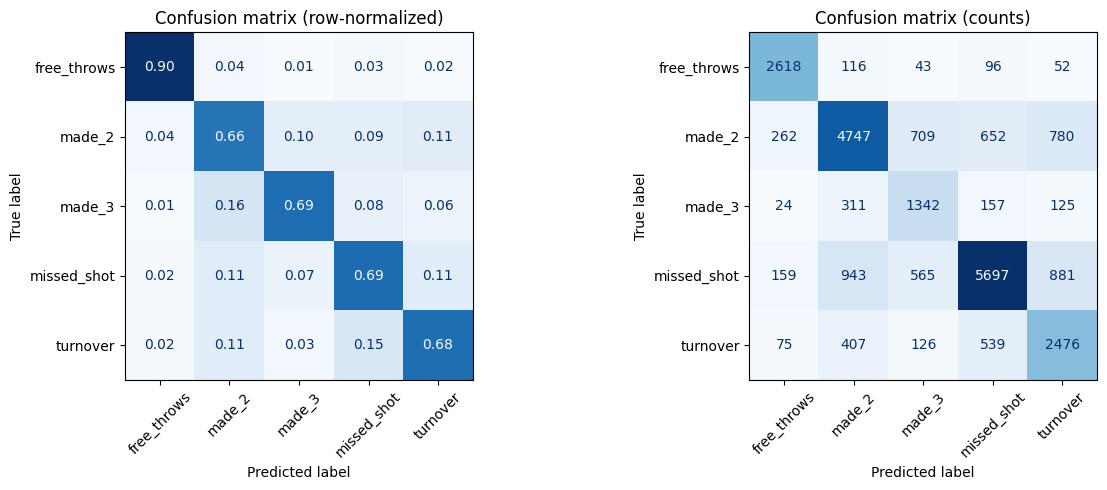

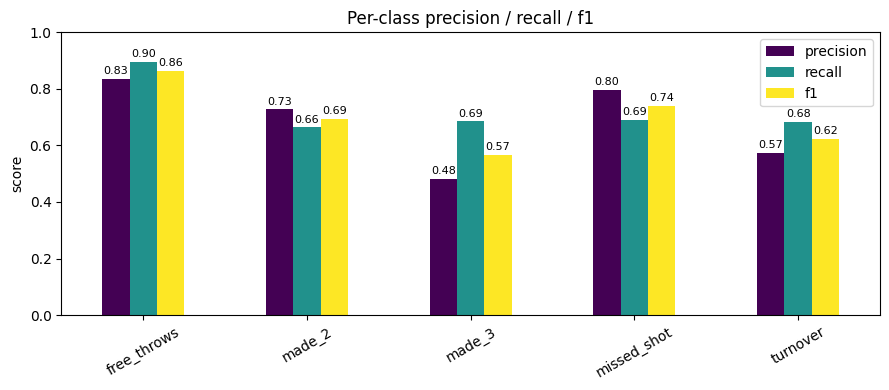

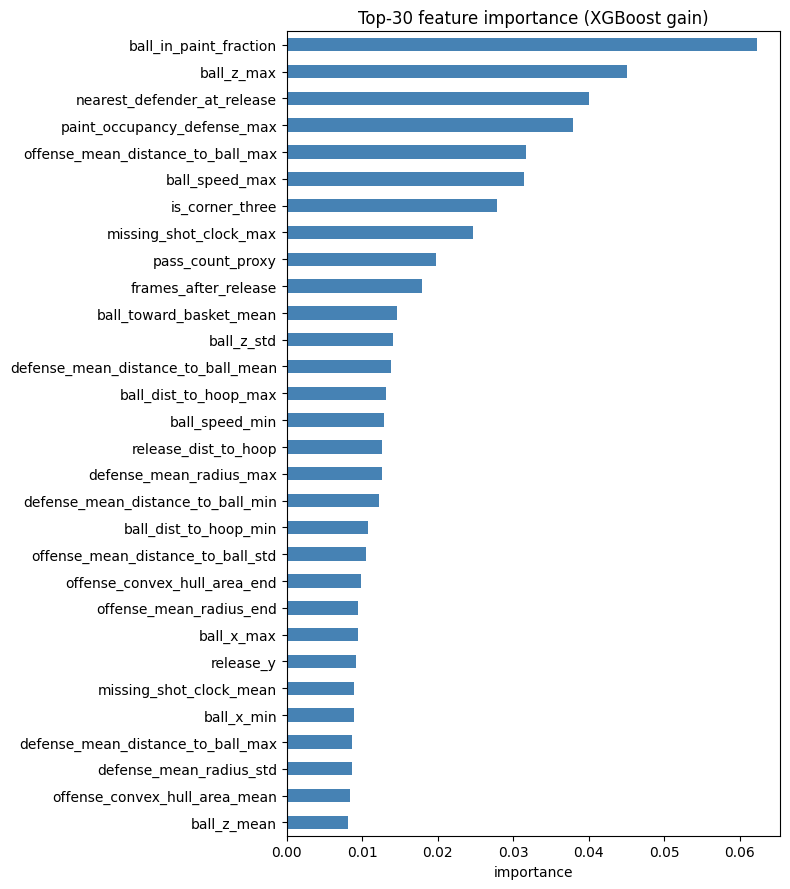

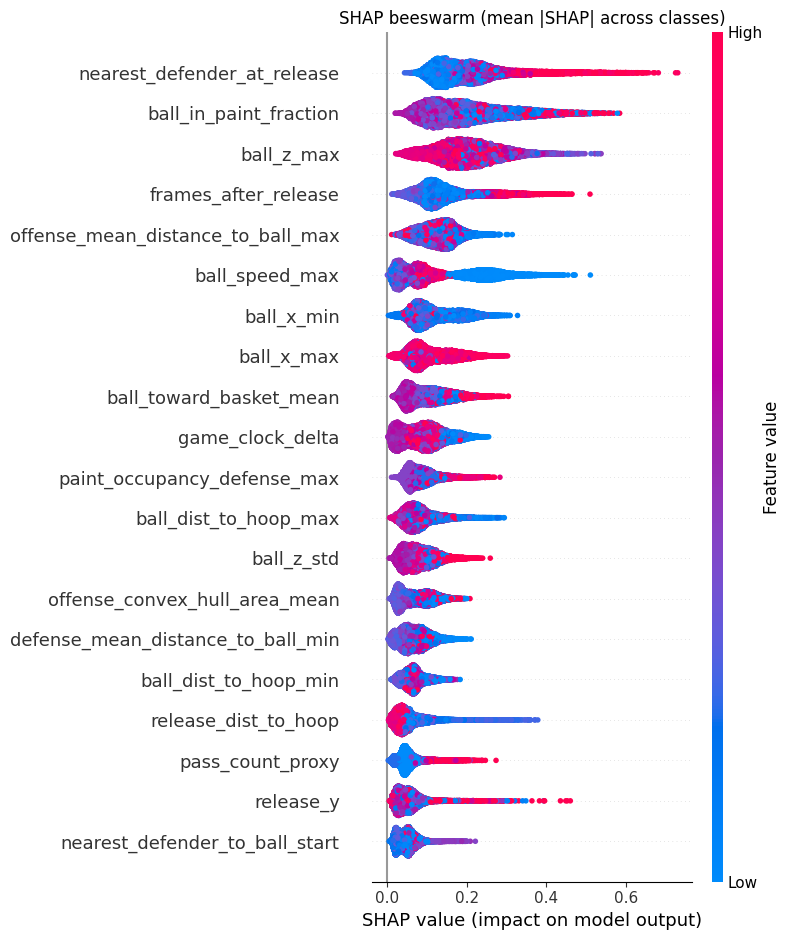

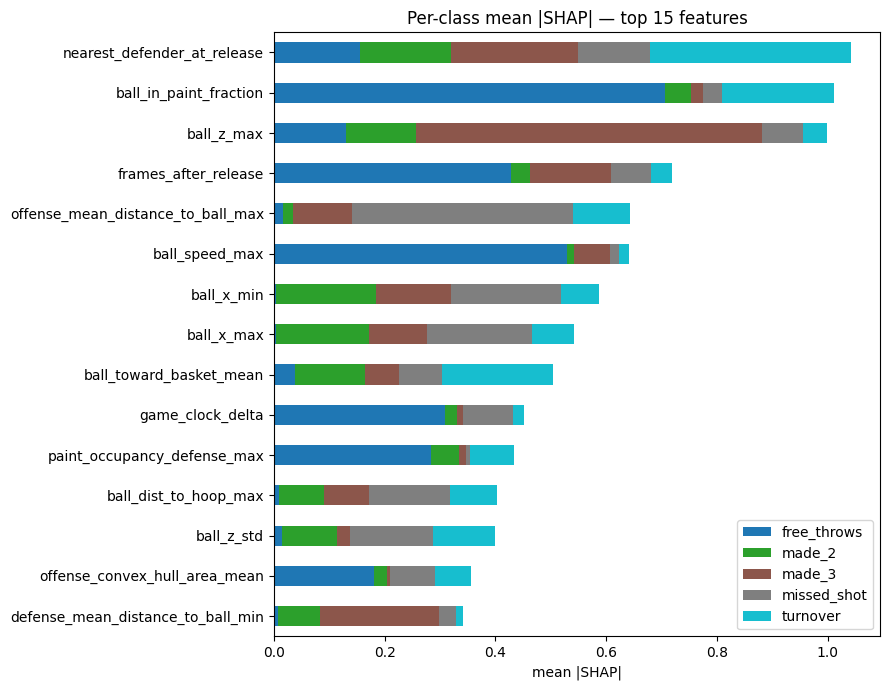

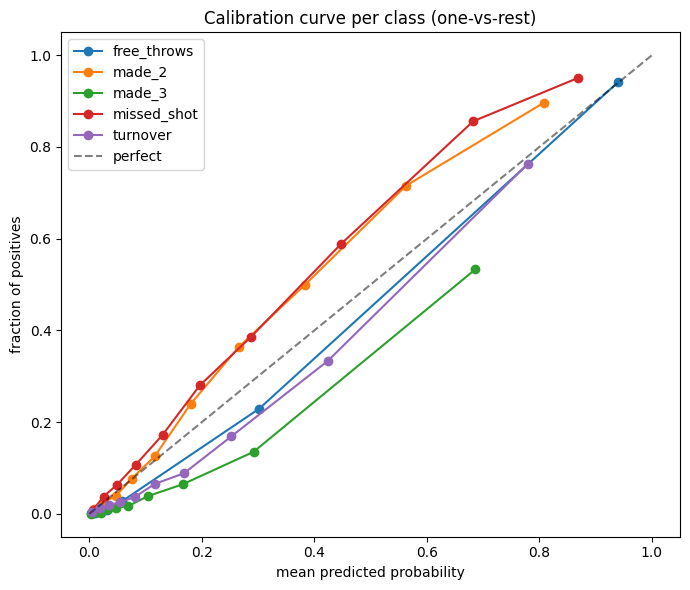

Analysis done.


In [14]:
# === Analysis cell: 6 diagnostic plots ===
# pip install shap if missing
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve

class_names = list(le.classes_)
proba = model.predict_proba(X_test)

# ---- 1. Confusion matrix heatmap (normalized rows) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=class_names,
    normalize="true", cmap="Blues", ax=axes[0], colorbar=False, values_format=".2f"
)
axes[0].set_title("Confusion matrix (row-normalized)")
axes[0].tick_params(axis="x", rotation=45)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=class_names,
    cmap="Blues", ax=axes[1], colorbar=False
)
axes[1].set_title("Confusion matrix (counts)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ---- 2. Per-class precision / recall / f1 bars ----
prec, rec, f1, sup = precision_recall_fscore_support(y_test, pred, zero_division=0)
metrics_df = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1}, index=class_names)
ax = metrics_df.plot(kind="bar", figsize=(9, 4), ylim=(0, 1), rot=30, colormap="viridis")
ax.set_title("Per-class precision / recall / f1")
ax.set_ylabel("score")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

# ---- 3. Top-30 feature importance bar ----
imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
top30 = imp.tail(30)
fig, ax = plt.subplots(figsize=(8, 9))
top30.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top-30 feature importance (XGBoost gain)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

# ---- 4. SHAP summary beeswarm (global, multiclass collapsed via |SHAP|) ----
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # list per class for multiclass
# For XGBoost sklearn API, shap_values may be array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv_stack = np.stack(shap_values, axis=-1)  # (n, f, c)
else:
    sv_stack = shap_values
mean_abs = np.abs(sv_stack).mean(axis=-1)      # collapse classes -> (n, f)
shap.summary_plot(mean_abs, X_test, feature_names=feat_cols,
                  max_display=20, show=False, plot_type="dot")
plt.title("SHAP beeswarm (mean |SHAP| across classes)")
plt.tight_layout(); plt.show()

# ---- 5. SHAP per-class bar (which features drive each class) ----
mean_abs_per_class = np.abs(sv_stack).mean(axis=0)   # (f, c)
shap_class_df = pd.DataFrame(mean_abs_per_class, index=feat_cols, columns=class_names)
top_feats = shap_class_df.sum(axis=1).sort_values(ascending=False).head(15).index
shap_class_df.loc[top_feats].plot(
    kind="barh", stacked=True, figsize=(9, 7), colormap="tab10"
)
plt.gca().invert_yaxis()
plt.title("Per-class mean |SHAP| — top 15 features")
plt.xlabel("mean |SHAP|")
plt.tight_layout(); plt.show()

# ---- 6. Calibration curve per class (one-vs-rest) ----
fig, ax = plt.subplots(figsize=(7, 6))
for i, cname in enumerate(class_names):
    y_bin = (y_test == i).astype(int)
    frac_pos, mean_pred = calibration_curve(y_bin, proba[:, i], n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=cname)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("fraction of positives")
ax.set_title("Calibration curve per class (one-vs-rest)")
ax.legend()
plt.tight_layout(); plt.show()

print("Analysis done.")
